# 01 · Data profiling

**KavionLens360 · Bank Customer 360 & Segmentation**

Purpose: complete the profiling checklist of spec section 7.1 on the raw file *before* any cleaning,
and overwrite every `[D]` value in the spec that the data contradicts.

Evidence tags: **[D]** dataset fact (verified here) · **[A]** project assumption · **[P]** proposed / derived.
The data is a public Kaggle dataset from an Indian bank (2016). It is **not** ICICI data.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from c360 import db, viz
from c360.config import FIG_DIR
viz.apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

## 1. Load the raw file exactly as delivered (all columns as text)

In [2]:
import zipfile
from c360.config import RAW_ZIP, RAW_MEMBER
with zipfile.ZipFile(RAW_ZIP) as zf:
    raw = pd.read_csv(zf.open(RAW_MEMBER), dtype=str, keep_default_na=False, na_values=[""])
raw.shape

(1048567, 9)

In [3]:
summary = pd.DataFrame({
    "dtype (raw)": raw.dtypes.astype(str),
    "nulls": raw.isna().sum(),
    "null %": (100 * raw.isna().mean()).round(3),
    "distinct": raw.nunique(),
    "example": raw.iloc[0],
})
summary

,dtype (raw),nulls,null %,distinct,example
TransactionID,str,0,0.00,1048567,T1
CustomerID,str,0,0.00,884265,C5841053
CustomerDOB,str,0,0.00,17255,10/1/94
CustGender,str,1100,0.10,3,F
CustLocation,str,151,0.01,9355,JAMSHEDPUR
CustAccountBalance,str,2369,0.23,161328,17819.05
TransactionDate,str,0,0.00,55,2/8/16
TransactionTime,str,0,0.00,81918,143207
TransactionAmount (INR),str,0,0.00,93024,25


## 2. Numeric columns: percentiles, zeros and outliers

In [4]:
amt = pd.to_numeric(raw["TransactionAmount (INR)"])
bal = pd.to_numeric(raw["CustAccountBalance"])
pct = [0, .01, .25, .5, .75, .9, .95, .99, .999, 1]
pd.DataFrame({"TransactionAmount (INR)": amt.quantile(pct), "CustAccountBalance": bal.quantile(pct)}).rename_axis("quantile")

,TransactionAmount (INR),CustAccountBalance
quantile,,
0.00,0.00,0.00
0.01,8.00,3.23
0.25,161.00,"4,721.76"
0.50,459.03,"16,792.18"
0.75,"1,200.00","57,657.36"
0.90,"2,947.06","198,504.25"
0.95,"5,200.00","416,164.55"
0.99,"20,000.00","1,586,901.17"
1.00,"95,000.00","7,004,727.98"


In [5]:
pd.Series({
    "amount = 0": int((amt == 0).sum()),
    "amount < 0": int((amt < 0).sum()),
    "balance = 0": int((bal == 0).sum()),
    "balance < 1": int((bal < 1).sum()),
    "balance < 0": int((bal < 0).sum()),
    "share of balance = 0 (%)": round(100 * (bal == 0).mean(), 3),
}, name="count").to_frame()

,count
amount = 0,835.00
amount < 0,0.00
balance = 0,"2,711.00"
balance < 1,"6,711.00"
balance < 0,0.00
share of balance = 0 (%),0.26


## 3. Dates, times and the DOB placeholder

In [6]:
txn_date = pd.to_datetime(raw["TransactionDate"], format="%d/%m/%y", errors="coerce")
dob_placeholder = (raw["CustomerDOB"] == "1/1/1800")
t = pd.to_numeric(raw["TransactionTime"])
bad_time = ((t // 10000) >= 24) | (((t // 100) % 100) >= 60) | ((t % 100) >= 60)
pd.Series({
    "TransactionDate unparsed": int(txn_date.isna().sum()),
    "TransactionDate min": txn_date.min().date(),
    "TransactionDate max": txn_date.max().date(),
    "DOB = 1/1/1800 (rows)": int(dob_placeholder.sum()),
    "DOB = 1/1/1800 (%)": round(100 * dob_placeholder.mean(), 2),
    "TransactionTime min / max": f"{t.min()} / {t.max()}",
    "TransactionTime not valid HHMMSS": int(bad_time.sum()),
}, name="value").to_frame()

,value
TransactionDate unparsed,0
TransactionDate min,2016-08-01
TransactionDate max,2016-10-21
DOB = 1/1/1800 (rows),57339
DOB = 1/1/1800 (%),5.47
TransactionTime min / max,0 / 235959
TransactionTime not valid HHMMSS,0


`TransactionTime` is a valid `HHMMSS` integer on every row (leading zeros dropped), not a Unix timestamp
as the Kaggle page suggests. **AS-11 is confirmed.**

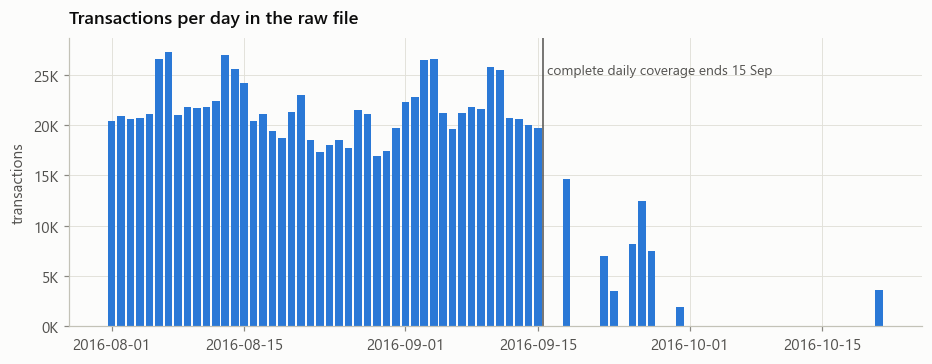

In [7]:
daily = txn_date.value_counts().sort_index()
full = pd.date_range(daily.index.min(), daily.index.max())
daily = daily.reindex(full, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(daily.index, daily.values, width=0.8, color=viz.SERIES[0])
ax.axvline(pd.Timestamp("2016-09-15") + pd.Timedelta(hours=12), color=viz.INK_2, linewidth=1)
ax.annotate("complete daily coverage ends 15 Sep", xy=(pd.Timestamp("2016-09-16"), daily.max() * 0.92),
            fontsize=9, color=viz.INK_2)
ax.set_title("Transactions per day in the raw file")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_ylabel("transactions")
viz.save(fig, "P0_daily_coverage"); fig

In [8]:
after = daily[daily.index > "2016-09-15"]
pd.Series({
    "days 1 Aug - 15 Sep with zero rows": int((daily[: "2016-09-15"] == 0).sum()),
    "mean rows/day 1 Aug - 15 Sep": round(daily[: "2016-09-15"].mean()),
    "days 16 Sep - 21 Oct with any rows": int((after > 0).sum()),
    "rows 16 Sep - 21 Oct": int(after.sum()),
    "share of rows after 15 Sep (%)": round(100 * after.sum() / daily.sum(), 2),
}, name="value").to_frame()

,value
days 1 Aug - 15 Sep with zero rows,0.00
mean rows/day 1 Aug - 15 Sep,"21,516.00"
days 16 Sep - 21 Oct with any rows,9.00
rows 16 Sep - 21 Oct,"58,826.00"
share of rows after 15 Sep (%),5.61


**Finding (coverage).** Every day from 1 Aug to 15 Sep 2016 has roughly 17-27K transactions. After 15 Sep the
file has only a handful of scattered days (and 3,652 rows on 21 Oct). That is an extract boundary, not customer
behaviour. Recency, "active", "dormant" and trend measures all assume complete coverage, so the analysis
window is set to **1 Aug - 15 Sep 2016 (46 days)**, as-of date **16 Sep 2016**, and the sparse tail is logged in
`rejected_rows` with reason `PARTIAL_COVERAGE_PERIOD` **[A]**. The spec's 30/60-day rules are scaled to the
46-day window (active ≤ 15 days, dormant > 30 days).

## 4. Customers: transactions per customer and attribute conflicts

In [9]:
per_cust = raw.groupby("CustomerID").size()
dist = per_cust.value_counts().sort_index()
pd.DataFrame({"customers": dist, "% of customers": (100 * dist / dist.sum()).round(2)}).rename_axis("transactions per customer")

,customers,% of customers
transactions per customer,,
1,740653,83.76
2,124960,14.13
3,16789,1.90
4,1702,0.19
5,147,0.02
6,14,0.00


In [10]:
rep = raw[raw["CustomerID"].isin(per_cust[per_cust > 1].index)]
conf = rep.groupby("CustomerID").agg(dob=("CustomerDOB", "nunique"), gender=("CustGender", "nunique"),
                                     location=("CustLocation", "nunique"))
pd.Series({
    "repeat CustomerIDs": len(conf),
    "with >1 DOB (%)": round(100 * (conf["dob"] > 1).mean(), 1),
    "with >1 gender (%)": round(100 * (conf["gender"] > 1).mean(), 1),
    "with >1 location (%)": round(100 * (conf["location"] > 1).mean(), 1),
    "consistent on all three (%)": round(100 * ((conf <= 1).all(axis=1)).mean(), 1),
}, name="value").to_frame()

,value
repeat CustomerIDs,"143,612.00"
with >1 DOB (%),99.10
with >1 gender (%),41.70
with >1 location (%),96.10
consistent on all three (%),0.70


**Finding (CustomerID).** Fewer than 1% of repeat CustomerIDs keep the same DOB, gender and location across
their rows, so in this public extract a CustomerID does not reliably identify one person (AS-02). The project keeps
CustomerID as the customer key, as the spec requires, resolves conflicts with the spec 8.3 rule (most frequent value,
then latest) and reports the finding in the DQ scorecard (`DQ-20`). Repeat-customer features (frequency, trend,
volatility) are therefore read with caution.

## 5. Categories: gender and location text

In [11]:
display(raw["CustGender"].value_counts(dropna=False).rename("rows").to_frame())
norm = (raw["CustLocation"].str.upper().str.replace(r"[^A-Z0-9 ]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True).str.strip())
pd.Series({"distinct raw locations": raw["CustLocation"].nunique(),
           "distinct after trim / upper / punctuation": norm.nunique()}, name="count").to_frame()

,rows
CustGender,
M,765530
F,281936
NaN,1100
T,1


,count
distinct raw locations,9355
distinct after trim / upper / punctuation,9061


## 6. Spec 7.1 values vs this file

In [12]:
check = pd.DataFrame([
    ("Rows", "1,048,567", f"{len(raw):,}"),
    ("Columns", "9", f"{raw.shape[1]}"),
    ("Unique customers", "884,265", f"{raw['CustomerID'].nunique():,}"),
    ("TransactionID unique", "yes", "yes" if raw['TransactionID'].is_unique else "no"),
    ("Date range", "1 Aug - 21 Oct 2016", f"{txn_date.min():%d %b} - {txn_date.max():%d %b %Y}"),
    ("Missing CustomerDOB", "3,397", f"{raw['CustomerDOB'].isna().sum():,}"),
    ("Missing CustGender", "1,100", f"{raw['CustGender'].isna().sum():,}"),
    ("Missing CustAccountBalance", "2,369", f"{raw['CustAccountBalance'].isna().sum():,}"),
    ("Missing CustLocation", "~151", f"{raw['CustLocation'].isna().sum():,}"),
    ("DOB 1/1/1800 share", "~5%", f"{100 * dob_placeholder.mean():.2f}%"),
    ("TransactionTime format", "unix timestamp? verify", "HHMMSS integer"),
], columns=["Item", "Spec 7.1 [D]", "Verified"])
check["Match"] = ["yes", "yes", "yes", "yes", "range yes; coverage only to 15 Sep", "yes", "yes", "yes", "yes", "yes", "resolved"]
check

,Item,Spec 7.1 [D],Verified,Match
0,Rows,"1,048,567","1,048,567",yes
1,Columns,9,9,yes
2,Unique customers,"884,265","884,265",yes
3,TransactionID unique,yes,yes,yes
4,Date range,1 Aug - 21 Oct 2016,01 Aug - 21 Oct 2016,range yes; coverage only to 15 Sep
5,Missing CustomerDOB,"3,397",0,yes
6,Missing CustGender,"1,100","1,100",yes
7,Missing CustAccountBalance,"2,369","2,369",yes
8,Missing CustLocation,~151,151,yes
9,DOB 1/1/1800 share,~5%,5.47%,yes


## Summary and decisions

| Finding | Decision | Tag |
|---|---|---|
| All row counts, nulls and the DOB placeholder match spec 7.1 | No change | [D] |
| `TransactionTime` is valid HHMMSS on every row | Parse as time of day (AS-11 confirmed) | [D] |
| Daily coverage is complete only to 15 Sep 2016 | Analysis window 1 Aug - 15 Sep; tail rows logged as `PARTIAL_COVERAGE_PERIOD` | [A] |
| Transactions of exactly ₹0 | Rejected as `ZERO_AMOUNT` (validity rule: amount > 0) | [A] |
| CustomerID is not a stable person key | Keep CustomerID per spec; resolve conflicts (8.3); report as DQ-20 | [A] |
| ~9.4K raw location spellings | Normalise + manual mapping table (`sql/01_location_map.sql`) | [P] |

Next: `sql/02_clean.sql` applies rules C1-C17 and writes the row waterfall.

In [13]:
db.query("SELECT step_no, step, rows FROM row_waterfall ORDER BY step_no")

,step_no,step,rows
0,0,Raw rows in staging,1048567
1,11,Rejected: PARTIAL_COVERAGE_PERIOD,-58826
2,12,Rejected: ZERO_AMOUNT,-794
3,99,Clean rows,988947
